<a href="https://colab.research.google.com/github/AdityaInTech/Task-Modules/blob/main/Week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**Iris Flower Clustering Project**






In [2]:
# Cell 1: Imports for Week 3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-Learn tools for Unsupervised Learning
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import joblib

**Load Data, Scale, and use the Elbow Method**

Loading Iris Dataset...


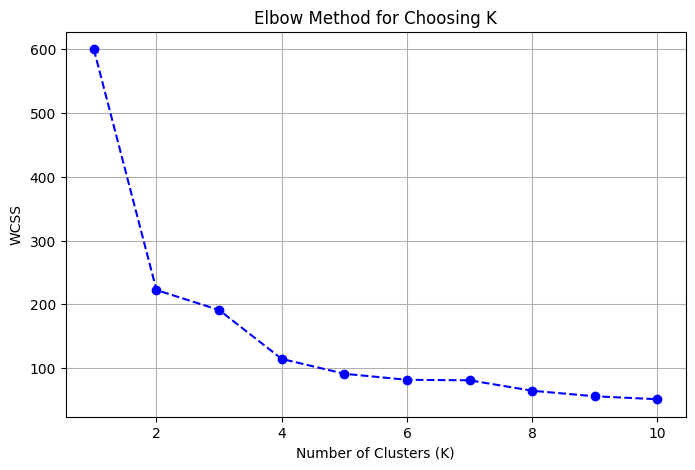

In [3]:
# Cell 2: Load Data & Elbow Method

# 1. Load Iris Dataset
print("Loading Iris Dataset...")
iris = load_iris()
X_iris = iris.data
y_true = iris.target # We will use this later to compare true labels

# 2. Scale the data (Best practice for K-Means and PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

# 3. Elbow method for choosing K
wcss = [] # Within-Cluster Sum of Square
for i in range(1, 11):
    kmeans_temp = KMeans(n_clusters=i, random_state=42)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Choosing K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

**Mini Project 3 - K-Means Clustering on Iris**

Cluster Centers:
 [[ 0.57100359 -0.37176778  0.69111943  0.66315198]
 [-0.81623084  1.31895771 -1.28683379 -1.2197118 ]
 [-1.32765367 -0.373138   -1.13723572 -1.11486192]]


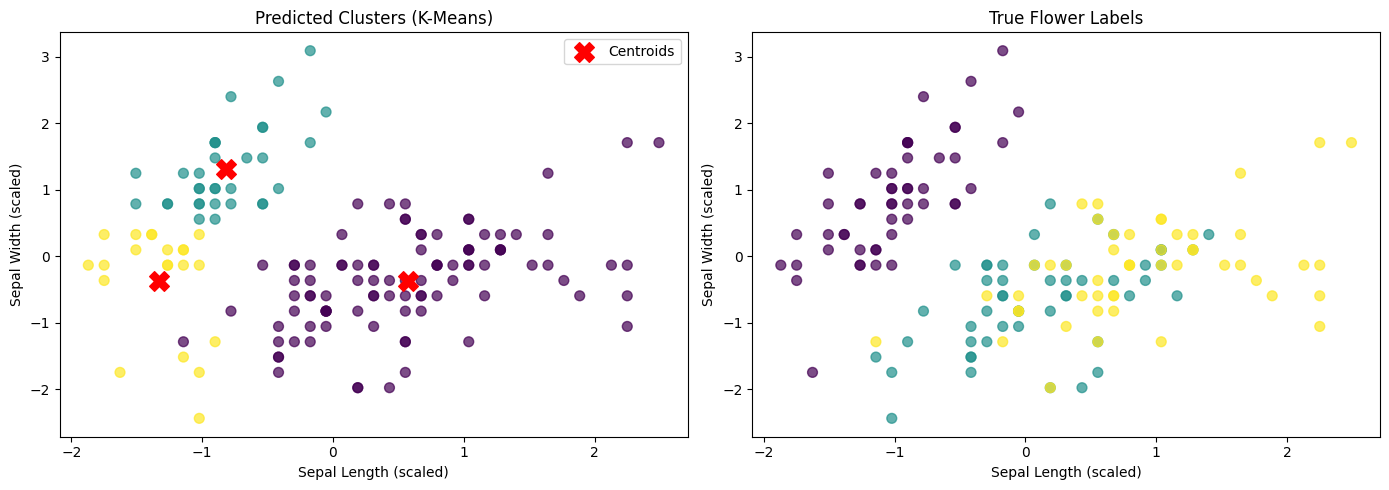

In [4]:
# Cell 3: K-Means Clustering (k=3) & Visualization

# 1. Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# 2. Print cluster centers
print("Cluster Centers:\n", kmeans.cluster_centers_)

# 3. Visualize and compare predicted clusters vs true labels
plt.figure(figsize=(14, 5))

# Plot A: Predicted Clusters
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis', s=50, alpha=0.7)
# Plot the centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.title('Predicted Clusters (K-Means)')
plt.xlabel('Sepal Length (scaled)')
plt.ylabel('Sepal Width (scaled)')
plt.legend()

# Plot B: True Labels
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.7)
plt.title('True Flower Labels')
plt.xlabel('Sepal Length (scaled)')
plt.ylabel('Sepal Width (scaled)')

plt.tight_layout()
plt.show()

**Principal Component Analysis (PCA)**

Explained Variance Ratio (Component 1): 72.96%
Explained Variance Ratio (Component 2): 22.85%
Total Explained Variance (Information retained): 95.81%



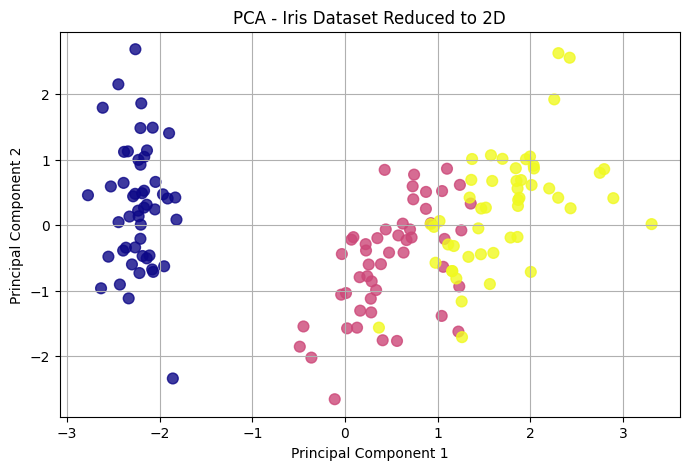

In [5]:
# Cell 4: PCA Dimensionality Reduction

# 1. Apply PCA to reduce dataset to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Find and print explained variance ratio
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance Ratio (Component 1): {explained_variance[0]*100:.2f}%")
print(f"Explained Variance Ratio (Component 2): {explained_variance[1]*100:.2f}%")
print(f"Total Explained Variance (Information retained): {sum(explained_variance)*100:.2f}%\n")

# 3. Visualize the 2D PCA data
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='plasma', s=60, alpha=0.8)
plt.title('PCA - Iris Dataset Reduced to 2D')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

**Model Saving and Loading**

In [7]:
# Cell 5: Model Saving/Loading using Joblib

# 1. Save the trained K-Means model to a file
model_filename = 'kmeans_iris_model.pkl'
joblib.dump(kmeans, model_filename)
print(f"Model successfully saved as '{model_filename}'")

# 2. Load the model back from the file
loaded_kmeans = joblib.load(model_filename)
print("\nModel successfully loaded!")

# Verify it works by printing the cluster centers from the loaded model
print("Loaded Model Cluster Centers:\n", loaded_kmeans.cluster_centers_)

Model successfully saved as 'kmeans_iris_model.pkl'

Model successfully loaded!
Loaded Model Cluster Centers:
 [[ 0.57100359 -0.37176778  0.69111943  0.66315198]
 [-0.81623084  1.31895771 -1.28683379 -1.2197118 ]
 [-1.32765367 -0.373138   -1.13723572 -1.11486192]]
